# Mini Project 5-3 Explore Sampling

## Introduction
In this project, you will engage in effective sampling of a dataset in order to make it easier to analyze. As a data professional you will often work with extremely large datasets, and utilizing proper sampling techniques helps you improve your efficiency in this work. 

For this project, you are a member of an analytics team for the Environmental Protection Agency. You are assigned to analyze data on air quality with respect to carbon monoxide—a major air pollutant—and report your findings. The data utilized in this project includes information from over 200 sites, identified by their state name, county name, city name, and local site name. You will use effective sampling within this dataset. 

## Step 1: Imports

### Import packages

Import `pandas`,  `numpy`, `matplotlib`, `statsmodels`, and `scipy`. 

In [6]:
# Import libraries and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

### Load the dataset

As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [9]:
# Import data.

modified_air_quality = pd.read_csv('modified_c4_epa_air_quality.csv')

## Step 2: Data exploration

### Examine the data

To understand how the dataset is structured, examine the first 10 rows of the data.

In [13]:
# First 10 rows of the data

modified_air_quality.head(10)

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log
0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,2.079442
1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,1.791759
2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,1.098612
3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,1.386294
4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,1.386294
5,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,2.708050
6,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,1.098612
7,2018-01-01,Pennsylvania,Erie,Erie,NaN,Carbon monoxide,Parts per million,1.098612
8,2018-01-01,Hawaii,Honolulu,Honolulu,Honolulu,Carbon monoxide,Parts per million,1.791759
9,2018-01-01,Colorado,Larimer,Fort Collins,Fort Collins - CSU - S. Mason,Carbon monoxide,Parts per million,1.945910


### Generate a table of descriptive statistics

Generate a table of some descriptive statistics about the data. Specify that all columns of the input be included in the output.

In [16]:
# Code Here

modified_air_quality.describe()

,aqi_log
count,260.000000
mean,1.766921
std,0.714716
min,0.000000
25%,1.098612
50%,1.791759
75%,2.302585
max,3.931826


**Question:** Based on the preceding table of descriptive statistics, what is the mean value of the `aqi` column? 

A: 1.766921

**Question:** Based on the preceding table of descriptive statistics, what do you notice about the count value for the `aqi` column?

A: 260 values for AQI.

### Use the `mean()` function on the `aqi`  column

Now, use the `mean()` function on the `aqi`  column and assign the value to a variable `population_mean`. The value should be the same as the one generated by the `describe()` method in the above table. 

In [23]:
# Code Here

population_mean = modified_air_quality['aqi_log'].mean()

print(population_mean)

1.7669210929985577


## Step 3: Statistical tests

### Sample with replacement

First, name a new variable `sampled_data`. Then, use the `sample()` dataframe method to draw 50 samples from `epa_data`. Set `replace` equal to `'True'` to specify sampling with replacement. For `random_state`, choose an arbitrary number for random seed. Make that arbitrary number `42`.

In [27]:
# Code Here

sampled_data = modified_air_quality.sample(n=50, replace=True, random_state=42)

### Output the first 10 rows

Output the first 10 rows of the DataFrame. 

In [30]:
# Code Here

sampled_data.head(10)

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log
102,2018-01-01,Texas,Harris,Houston,Clinton,Carbon monoxide,Parts per million,1.098612
106,2018-01-01,California,Imperial,Calexico,Calexico-Ethel Street,Carbon monoxide,Parts per million,3.295837
71,2018-01-01,Alabama,Jefferson,Birmingham,Arkadelphia/Near Road,Carbon monoxide,Parts per million,1.098612
188,2018-01-01,Arizona,Maricopa,Tempe,Diablo,Carbon monoxide,Parts per million,2.397895
20,2018-01-01,Virginia,Roanoke,Vinton,East Vinton Elementary School,Carbon monoxide,Parts per million,0.693147
102,2018-01-01,Texas,Harris,Houston,Clinton,Carbon monoxide,Parts per million,1.098612
121,2018-01-01,North Carolina,Mecklenburg,Charlotte,Garinger High School,Carbon monoxide,Parts per million,1.098612
214,2018-01-01,Florida,Broward,Davie,Daniela Banu NCORE,Carbon monoxide,Parts per million,1.791759
87,2018-01-01,California,Humboldt,Eureka,Jacobs,Carbon monoxide,Parts per million,1.791759
99,2018-01-01,California,Santa Barbara,Goleta,Goleta,Carbon monoxide,Parts per million,1.386294


**Question:** In the DataFrame output, why is the row index 102 repeated twice? 

A: Because the code had replacement, so the same index could be retrieved multiple times

**Question:** What does `random_state` do?

A: Assigns a seed for each specific iteration

### Compute the mean value from the `aqi` column

Compute the mean value from the `aqi` column in `sampled_data` and assign the value to the variable `sample_mean`.

In [37]:
# Code Here

sample_mean = sampled_data['aqi_log'].mean()
print(sample_mean)

1.6379981384419398


 **Question:**  Why is `sample_mean` different from `population_mean`?


A: Because the sample_mean is only taking a small section of the entire dataset

### Apply the central limit theorem

Imagine repeating the the earlier sample with replacement 10,000 times and obtaining 10,000 point estimates of the mean. In other words, imagine taking 10,000 random samples of 50 AQI values and computing the mean for each sample. According to the **central limit theorem**, the mean of a sampling distribution should be roughly equal to the population mean. Complete the following steps to compute the mean of the sampling distribution with 10,000 samples. 

* Create an empty list and assign it to a variable called `estimate_list`. 
* Iterate through a `for` loop 10,000 times. To do this, make sure to utilize the `range()` function to generate a sequence of numbers from 0 to 9,999. 
* In each iteration of the loop, use the `sample()` function to take a random sample (with replacement) of 50 AQI values from the population. Do not set `random_state` to a value.
* Use the list `append()` function to add the value of the sample `mean` to each item in the list.


In [42]:
# Code Here
estimate_list = []
for i in range(9999):
    estimate_list.append(modified_air_quality['aqi_log'].sample(n=50, replace=True).mean())

#print(estimate_list)

### Create a new DataFrame

Next, create a new DataFrame from the list of 10,000 estimates. Name the new variable `estimate_df`.

In [44]:
# Code Here

estimate_df = pd.DataFrame(data={'estimate': estimate_list})

### Compute the mean() of the sampling distribution

Next, compute the `mean()` of the sampling distribution of 10,000 random samples and store the result in a new variable `mean_sample_means`.

In [48]:
# Code Here
mean_sample_means = estimate_df.mean()


**Question:** What is the mean for the sampling distribution of 10,000 random samples?

In [51]:
# Code Here
print(mean_sample_means)

estimate    1.766443
dtype: float64


**Question:** How are the central limit theorem and random sampling (with replacement) related?

In [54]:
# Code Here
print(population_mean)
print(mean_sample_means)

1.7669210929985577
estimate    1.766443
dtype: float64


A: CLT and random sampling are closely related. CLT says that sampled values of a distribution (no matter the distribution) create a normal distribution. CLT relies on the fact that sample means taken are independent which is confirmed by the fact that they are sampled RANDOMLY. This ensures indendence.

### Output the distribution using a histogram

Output the distribution of these estimates using a histogram. This provides an idea of the sampling distribution.

array([[<Axes: title={'center': 'estimate'}>]], dtype=object)

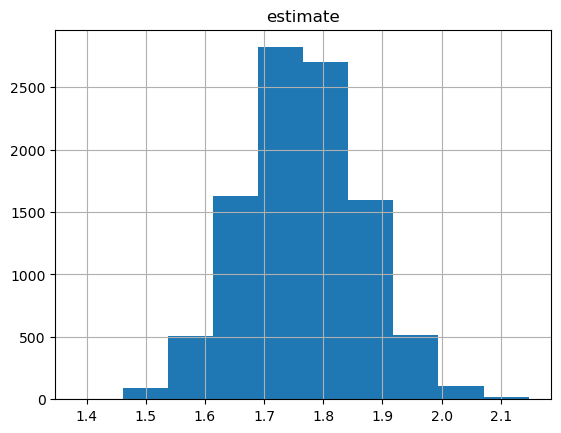

In [58]:
# Code Here

estimate_df.hist()

### Calculate the standard error

Calculate the standard error of the mean AQI using the initial sample of 50. The **standard error** of a statistic measures the sample-to-sample variability of the sample statistic. It provides a numerical measure of sampling variability and answers the question: How far is a statistic based on one particular sample from the actual value of the statistic?

In [61]:
# Code Here

sampled_data_std = sampled_data['aqi_log'].std()

standard_error = (sampled_data_std)/(50** 0.5)

print(standard_error)

0.0945235150131964


## Step 4: Results and evaluation

###  Visualize the relationship between the sampling and normal distributions

Visualize the relationship between your sampling distribution of 10,000 estimates and the normal distribution.

1. Plot a histogram of the 10,000 sample means 
2. Add a vertical line indicating the mean of the first single sample of 50
3. Add another vertical line indicating the mean of the means of the 10,000 samples 
4. Add a third vertical line indicating the mean of the actual population

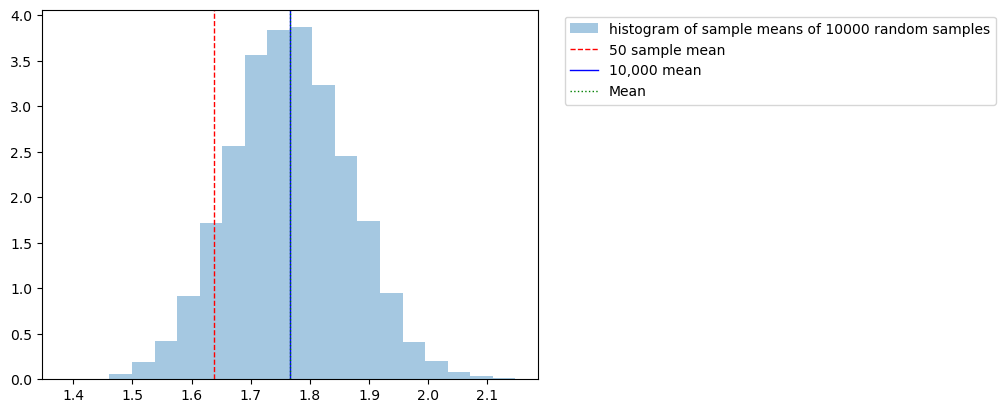

In [69]:
# Code Here
plt.hist(estimate_df['estimate'], bins=20, density=True, alpha=0.4, label = "histogram of sample means of 10000 random samples")
plt.axvline(x=sample_mean, color='red', linestyle='dashed', linewidth=1, label='50 sample mean')
plt.axvline(x=mean_sample_means.mean(), color='blue', linestyle='solid', linewidth=1, label='10,000 mean')
plt.axvline(x=modified_air_quality['aqi_log'].mean(), color='green', linestyle=':', linewidth=1, label='Mean')
plt.legend(bbox_to_anchor=(1.04,1))


In [67]:
print(population_mean)
print(sample_mean)
print(mean_sample_means)
#why won't the population mean show up?

1.7669210929985577
1.6379981384419398
estimate    1.766443
dtype: float64



**Question:** What insights did you gain from the preceding sampling distribution?

A: Shows that as you get more samples, the means form a normal distribution

# Considerations

**What are some key takeaways that you learned from this project?**

A: Learned how the CLT presents a normal distribution of sample means.

**What findings would you share with others?**

A: Show that through this lab I confirmed the CLT

**What would you convey to external readers?**

A: The mean of sample means converges to a normal distribution